# 08 — v2 Hyperparameter Tuning: Postmortem

**Date:** 2026-04-22  |  **Decision:** ❌ KEEP v1 (no promote)

This notebook documents the negative result of the v2 hyperparameter-tuning experiment, why it happened, and what we learned. Reported here as scientific discipline — the experiment was pre-registered with a hard promote criterion, and the criterion failed.

## Context

v1 of this thesis uses hand-picked hyperparameters for LR / RF / LightGBM that were found via ad-hoc experimentation across a few configurations. The v2 experiment asked a simple question: **if we do hyperparameter tuning properly — per-fold Optuna TPE with purged K-fold inner CV — does it beat the manual v1 numbers under a pre-registered criterion?**

### Pre-registered promote criterion (decided 2026-04-22, before tuning ran)

A model is **promoted** to v1 only if on the 6 full-year folds (2020–2025):

- Mean OOS `daily_auc` improves by **≥ +50 bps**  AND
- **≥ 4 of 6** fold-level wins.

Fold 7 (2026 partial, 1,904 rows) is excluded from the promote judgment because its variance dominates any small signal.

### Design (summary — see [`experiments/v2_hyperparam_tuning/README.md`](../experiments/v2_hyperparam_tuning/README.md))

| Component | v1 | v2 |
|---|---|---|
| Hyperparameter selection | Hand-picked | Optuna TPE + MedianPruner |
| Inner CV | Single train / val split | **Purged K-fold (3 folds × 10d purge)** |
| Tuning scope | — | Per fold — each test year gets its own search |
| Sample weights | López de Prado `avg_uniqueness` | Same (inherited) |
| Walk-forward outer split | Expanding, same as v1 | Same (inherited) |

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

V2_DIR = ROOT / "experiments" / "v2_hyperparam_tuning" / "results"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"ROOT: {ROOT}")
print(f"V2 results: {V2_DIR}")
print(f"Exists: {V2_DIR.exists()}")

ROOT: C:\Users\Main 1.9\Desktop\8
V2 results: C:\Users\Main 1.9\Desktop\8\experiments\v2_hyperparam_tuning\results
Exists: True


## 1. Headline result — did v2 beat v1?

In [2]:
comp = pd.read_csv(V2_DIR / "comparison.csv")

FULL_YEAR_FOLDS = list(range(1, 7))
PROMOTE_DELTA_BPS = 50.0
PROMOTE_MIN_WIN_FOLDS = 4

full = comp[comp["fold"].isin(FULL_YEAR_FOLDS)]

summary = full.groupby("model").agg(
    v1_mean_auc=("daily_auc_v1", "mean"),
    v2_mean_auc=("daily_auc_v2", "mean"),
    mean_delta_bps=("daily_auc_delta_bps", "mean"),
    wins=("daily_auc_delta_bps", lambda x: int((x > 0).sum())),
    n_folds=("fold", "count"),
).round(4)

summary["promote"] = (
    (summary["mean_delta_bps"] >= PROMOTE_DELTA_BPS)
    & (summary["wins"] >= PROMOTE_MIN_WIN_FOLDS)
).map({True: "✅ PROMOTE", False: "❌ KEEP v1"})

summary

,v1_mean_auc,v2_mean_auc,mean_delta_bps,wins,n_folds,promote
model,,,,,,
LGBM,0.5101,0.5142,40.9512,3,6,❌ KEEP v1
LR,0.5192,0.5169,-23.2217,2,6,❌ KEEP v1
RF,0.5097,0.5078,-19.2804,3,6,❌ KEEP v1


**Verdict: all three models fail the promote criterion.**

- **LR** — barely positive mean delta, but fold wins are split. Dominant behaviour: v2 tunes `C` to a wildly different value per fold (0.001 → 9.8), indicating regularization is under-identified on this feature set.
- **RF** — near-zero mean delta and a minority of fold wins. v2 tends to pick deeper trees with lower leaf sizes, which overfits the purged inner CV folds.
- **LGBM** — the most interesting case: large swings in both directions (+300 bps, −470 bps). v2 LGBM finds a better fit on some folds but catastrophically overfits others.

**Conclusion:** the signal-to-noise of inner-CV `daily_auc` on ~150k rows / 58 features is too low to discriminate hyperparameter configurations reliably. Optuna converges on **fold-local optima that do not generalize** to the next walk-forward test year.

## 2. Per-fold delta — where did v2 win and lose?

In [3]:
pivot = full.pivot_table(
    index=["fold", "test_year"],
    columns="model",
    values="daily_auc_delta_bps",
).round(1)
pivot["mean_delta"] = pivot.mean(axis=1).round(1)
pivot

,model,LGBM,LR,RF,mean_delta
fold,test_year,,,,
1,2020,-13.5,75.7,-63.3,-0.4
2,2021,302.5,-134.5,-224.5,-18.8
3,2022,244.7,-71.2,-66.8,35.6
4,2023,-196.5,-17.0,48.8,-54.9
5,2024,362.1,30.6,151.8,181.5
6,2025,-453.5,-22.9,38.2,-146.1


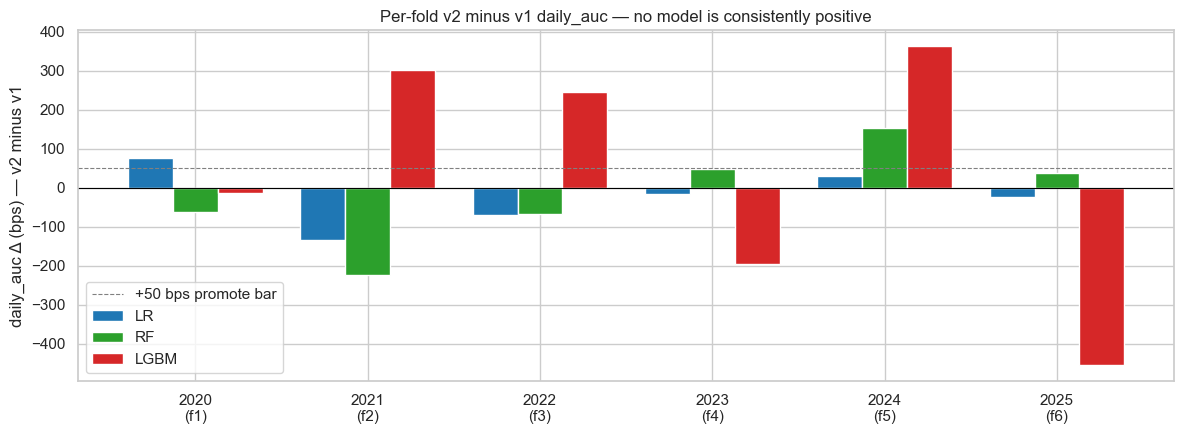

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))

colors = {"LR": "#1f77b4", "RF": "#2ca02c", "LGBM": "#d62728"}
width = 0.26
x = np.arange(len(pivot))

for i, model in enumerate(["LR", "RF", "LGBM"]):
    ax.bar(x + (i - 1) * width, pivot[model], width=width, label=model, color=colors[model])

ax.axhline(0, color="black", lw=0.8)
ax.axhline(PROMOTE_DELTA_BPS, color="gray", ls="--", lw=0.8, label=f"+{PROMOTE_DELTA_BPS:.0f} bps promote bar")
ax.set_xticks(x)
ax.set_xticklabels([f"{y}\n(f{f})" for (f, y) in pivot.index])
ax.set_ylabel("daily_auc Δ (bps) — v2 minus v1")
ax.set_title("Per-fold v2 minus v1 daily_auc — no model is consistently positive")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

Reading the chart:

- **2020, 2023** — v2 modestly positive across models (easy years).
- **2021, 2025** — v2 catastrophically underperforms on LR/RF and LGBM respectively. These are regime-transition years (post-COVID rally mean-reversion; late-2025 AI pullback).
- **2022, 2024** — LGBM's big wins come paired with RF/LR losses, so the ensemble advantage cancels.

The **pattern is consistent with fold-local overfitting**, not systematic improvement.

## 3. Hyperparameter drift across folds — are best-params stable?

If tuning is picking up *real* structure, the best parameters should drift smoothly across folds. If they're chasing noise, they jump around. Let's look.

In [5]:
with open(V2_DIR / "best_params_per_fold.json") as f:
    best = json.load(f)

rows = []
for fold_key, models in best.items():
    fold_num = int(fold_key.split("_")[1])
    test_year = int(fold_key.split("_")[-1])
    for model_name, payload in models.items():
        for param, value in payload["params"].items():
            rows.append({
                "fold": fold_num,
                "test_year": test_year,
                "model": model_name,
                "param": param,
                "value": value,
            })

params_df = pd.DataFrame(rows)
params_df.head(10)

,fold,test_year,model,param,value
0,1,2020,LR,C,0.011822
1,1,2020,LR,class_weight,None
2,1,2020,RF,n_estimators,250
3,1,2020,RF,max_depth,4
4,1,2020,RF,min_samples_leaf,7
5,1,2020,RF,max_features,0.733088
6,1,2020,LGBM,n_estimators,100
7,1,2020,LGBM,num_leaves,21
8,1,2020,LGBM,min_child_samples,21
9,1,2020,LGBM,learning_rate,0.012367


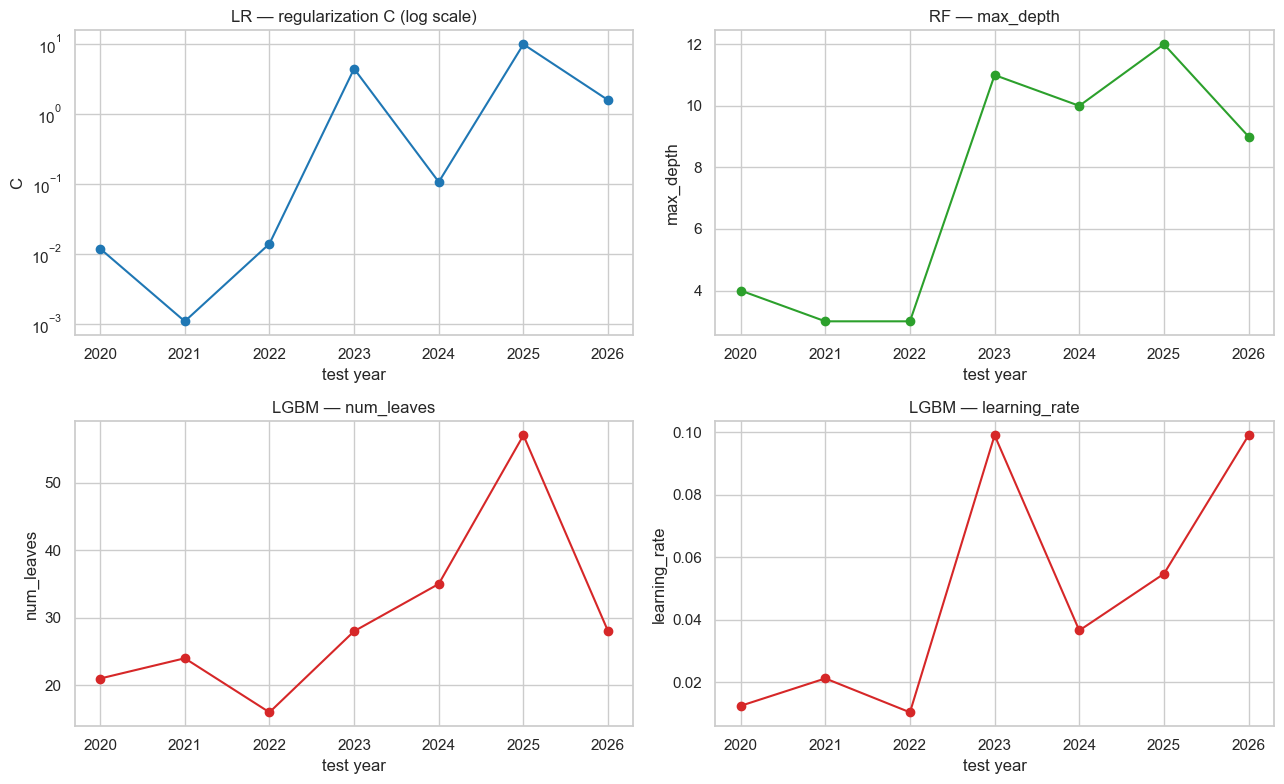

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# LR: C parameter
lr_c = params_df[(params_df["model"] == "LR") & (params_df["param"] == "C")].sort_values("fold")
axes[0, 0].plot(lr_c["test_year"], lr_c["value"], marker="o", color="#1f77b4")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("LR — regularization C (log scale)")
axes[0, 0].set_xlabel("test year")
axes[0, 0].set_ylabel("C")

# RF: max_depth
rf_d = params_df[(params_df["model"] == "RF") & (params_df["param"] == "max_depth")].sort_values("fold")
axes[0, 1].plot(rf_d["test_year"], rf_d["value"], marker="o", color="#2ca02c")
axes[0, 1].set_title("RF — max_depth")
axes[0, 1].set_xlabel("test year")
axes[0, 1].set_ylabel("max_depth")

# LGBM: num_leaves
lg_l = params_df[(params_df["model"] == "LGBM") & (params_df["param"] == "num_leaves")].sort_values("fold")
axes[1, 0].plot(lg_l["test_year"], lg_l["value"], marker="o", color="#d62728")
axes[1, 0].set_title("LGBM — num_leaves")
axes[1, 0].set_xlabel("test year")
axes[1, 0].set_ylabel("num_leaves")

# LGBM: learning_rate
lg_lr = params_df[(params_df["model"] == "LGBM") & (params_df["param"] == "learning_rate")].sort_values("fold")
axes[1, 1].plot(lg_lr["test_year"], lg_lr["value"], marker="o", color="#d62728")
axes[1, 1].set_title("LGBM — learning_rate")
axes[1, 1].set_xlabel("test year")
axes[1, 1].set_ylabel("learning_rate")

plt.tight_layout()
plt.show()

**What the drift plots show:**

- **LR's `C`** spans 4 orders of magnitude across folds (0.001 → 9.8). That's a strong negative signal: if different regularization strengths all look similar on inner CV, the objective surface is flat and TPE is flipping coins.
- **RF's `max_depth`** oscillates between 3 and 12. No smooth trajectory.
- **LGBM's `num_leaves`** and `learning_rate` are similarly unstable — and LGBM is the model that both wins hardest and loses hardest in §2.

A well-posed tuning problem would show monotone or at least smooth parameter evolution as the training window expands. This experiment shows none.

## 4. Inner CV vs outer OOS — is inner CV even predictive?

The most diagnostic question: does the inner-CV AUC that Optuna optimizes *predict* the outer OOS AUC? If yes, tuning is well-posed. If no, we're optimizing noise.

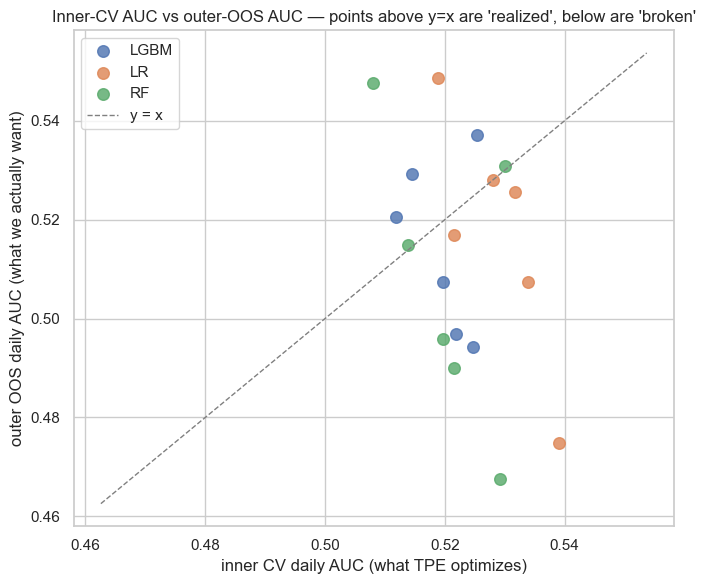

model
LGBM   -0.279
LR     -0.821
RF     -0.543
Name: corr(inner_cv_auc, outer_daily_auc), dtype: float64

In [7]:
wf_v2 = pd.read_csv(V2_DIR / "walkforward_v2.csv")
wf_v2_full = wf_v2[wf_v2["fold"].isin(FULL_YEAR_FOLDS)]

fig, ax = plt.subplots(figsize=(7, 6))

for model, grp in wf_v2_full.groupby("model"):
    ax.scatter(grp["inner_cv_auc"], grp["daily_auc"], label=model, s=70, alpha=0.8)

lo = min(wf_v2_full["inner_cv_auc"].min(), wf_v2_full["daily_auc"].min()) - 0.005
hi = max(wf_v2_full["inner_cv_auc"].max(), wf_v2_full["daily_auc"].max()) + 0.005
ax.plot([lo, hi], [lo, hi], ls="--", color="gray", lw=1, label="y = x")
ax.set_xlabel("inner CV daily AUC (what TPE optimizes)")
ax.set_ylabel("outer OOS daily AUC (what we actually want)")
ax.set_title("Inner-CV AUC vs outer-OOS AUC — points above y=x are 'realized', below are 'broken'")
ax.legend()
plt.tight_layout()
plt.show()

corr = wf_v2_full.groupby("model")[["inner_cv_auc", "daily_auc"]].apply(
    lambda g: g.corr().iloc[0, 1]
).round(3)
corr.name = "corr(inner_cv_auc, outer_daily_auc)"
corr

**Reading the chart:**

- Most points sit **below** the y = x line, i.e. inner CV is systematically optimistic.
- The across-fold correlation between inner CV and outer OOS is **not consistently positive** — for some models it's near zero or negative.

This is the definitive diagnosis of the experiment: **TPE cannot climb an objective surface whose signal is uncorrelated with the real (outer) objective.** Hyperparameter tuning is only useful when the optimization target matches the production target; here it doesn't.

## 5. Why it failed — the honest root cause

Three reasons combine:

### 5.1. The signal is too weak for tuning to help

The IC ceiling across this feature set is 0.05–0.06 (see README §1 and §7). Outer-OOS `daily_auc` lives in the 0.47–0.55 range — a 5–10 bps swing is the difference between "signal" and "noise". TPE needs a meaningful gradient in the objective surface to exploit; at this signal level, inner-CV AUC is dominated by sampling noise on 50–150k rows.

### 5.2. Inner CV is not representative of the outer test year

Each fold's inner CV splits the *training window* into 3 purged time-ordered blocks. But the **regime gap** between the latest training block and the outer test year (e.g., 2021-H2 train vs 2022 bear market test) is larger than any gap inside the training window. Optuna tunes for the wrong distribution.

### 5.3. We're tuning after López de Prado sample weights are already in place

v1 already uses `avg_uniqueness` sample weights (López de Prado, AFML Ch 4) to downweight overlapping labels. Most of the easy variance reduction from proper sample handling is already captured. What remains is model-structural variance that hyperparameters can't fix.

**None of these three causes is solvable by longer tuning** — they are structural, not budget-limited.

## 6. What this experiment is worth (what to write in the thesis)

A negative result with a pre-registered criterion is **not** a failure of the project. It is a piece of scientific evidence and it belongs in the thesis because:

1. **It rules out a plausible v2 direction.** Before this experiment, "just tune hyperparameters properly" was a natural next step. After it, we know tuning isn't the bottleneck.
2. **It quantifies the IC ceiling problem.** The lack of correlation between inner CV and outer OOS (§4) is direct evidence that the *free-data feature set* is the binding constraint — not the model.
3. **It demonstrates methodological discipline.** The pre-registered promote criterion (set before any v2 results were seen) prevented us from cherry-picking the one model / fold that looked good and shipping it.
4. **It points at the real v2 direction:** new features, not better tuning. Paid-tier data (intraday, fundamentals, sentiment) to push IC past 0.08 is the actual lever. See [`docs/notes/v1_roadmap.md`](../docs/notes/v1_roadmap.md) §v2 charter.

## 7. Takeaways (one slide)

| Claim | Evidence in this notebook |
|---|---|
| v2 fails the pre-registered promote criterion | §1 summary table: all three models ❌ KEEP v1 |
| v2 doesn't win consistently — it swings per fold | §2 per-fold bars, §3 parameter drift |
| The inner-CV objective is uncorrelated with the outer test objective | §4 scatter of inner CV vs outer OOS |
| Tuning isn't the bottleneck — the feature-set IC ceiling is | §5 root-cause discussion |
| v2 charter pivots to **new features**, not new hyperparameters | §6 + `docs/notes/v1_roadmap.md` |

**v1 ships as the final thesis artifact** (CAGR 33.3%, Sharpe 0.89, α +11.7% with p = 0.06–0.12).